## Explorando os dados

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Cauan\Desktop\Projetos Finanças (Data Analyst)\Projeto 01 Credit Risk(ETL, EDA)\Dados\dados_tratados.csv")
df.head()

,idade,renda_anual,situacao_moradia,tempo_emprego_anos,motivo_emprestimo,nota_risco,valor_emprestimo,taxa_juros,inadimplencia,comprometimento_renda%,historico_inadimplencia,anos_historico_credito,renda_mensal,faixa_etaria
0,22,59000,Aluguel,4,Pessoal,D,35000,16.02,Inadimplente,0.59,S,3,4917,Até 25 anos
1,21,9600,Própria,5,Educação,B,1000,11.14,Não Inadimplente,0.10,N,2,800,Até 25 anos
2,25,9600,Financiada,1,Saúde,C,5500,12.87,Inadimplente,0.57,N,3,800,Até 25 anos
3,23,65500,Aluguel,4,Saúde,C,35000,15.23,Inadimplente,0.53,N,2,5458,Até 25 anos
4,24,54400,Aluguel,8,Saúde,C,35000,14.27,Inadimplente,0.55,S,4,4533,Até 25 anos


Porcentagem de mau pagadores e bom pagadores(Atual e o historico)

In [5]:
round(df["inadimplencia"].value_counts(normalize=True) * 100,2)



inadimplencia
Não Inadimplente    78.18
Inadimplente        21.82
Name: proportion, dtype: float64

In [6]:
round(df["historico_inadimplencia"].value_counts(normalize=True) * 100,2)

historico_inadimplencia
N    82.36
S    17.64
Name: proportion, dtype: float64

Renda mensal média de clientes pagadores e não pagadores

In [7]:
dados = round(df.groupby("inadimplencia")["renda_mensal"].mean(),2)

print(dados)

inadimplencia
Inadimplente        4093.81
Não Inadimplente    5879.90
Name: renda_mensal, dtype: float64


In [8]:
df["1_0_coluna"] = df["inadimplencia"].apply(lambda x: 1 if x == "Inadimplente" else 0)

In [9]:
df.head()

,idade,renda_anual,situacao_moradia,tempo_emprego_anos,motivo_emprestimo,nota_risco,valor_emprestimo,taxa_juros,inadimplencia,comprometimento_renda%,historico_inadimplencia,anos_historico_credito,renda_mensal,faixa_etaria,1_0_coluna
0,22,59000,Aluguel,4,Pessoal,D,35000,16.02,Inadimplente,0.59,S,3,4917,Até 25 anos,1
1,21,9600,Própria,5,Educação,B,1000,11.14,Não Inadimplente,0.10,N,2,800,Até 25 anos,0
2,25,9600,Financiada,1,Saúde,C,5500,12.87,Inadimplente,0.57,N,3,800,Até 25 anos,1
3,23,65500,Aluguel,4,Saúde,C,35000,15.23,Inadimplente,0.53,N,2,5458,Até 25 anos,1
4,24,54400,Aluguel,8,Saúde,C,35000,14.27,Inadimplente,0.55,S,4,4533,Até 25 anos,1


C:\Users\Cauan\AppData\Local\Temp\ipykernel_22384\2166891850.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y])


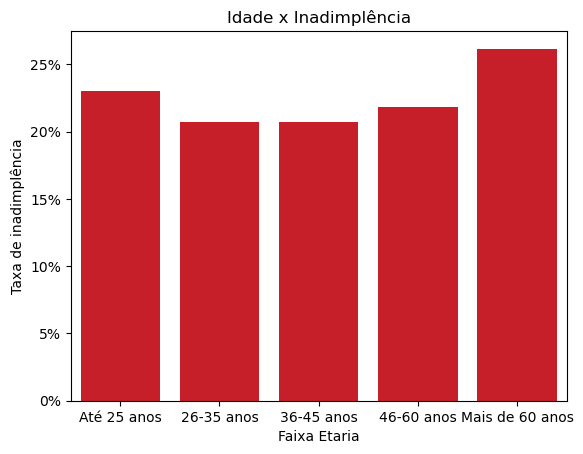

In [10]:
grafico = sns.barplot(data= df, x="faixa_etaria" , y="1_0_coluna", color= "#e30312", errorbar= None )
plt.title("Idade x Inadimplência")
plt.xlabel("Faixa Etaria")
plt.ylabel("Taxa de inadimplência")
valores_y = grafico.get_yticks()
grafico.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y])
plt.show()

## Qual faixa etária realmente representa o maior risco sistêmico para a carteira de crédito do banco?

O gráfico revela que clientes com 'Mais de 60 anos' possuem a maior taxa percentual de inadimplência (26.1%). No entanto, uma análise aprofundada da distribuição dos dados revelou que este grupo representa uma amostra ínfima da base (apenas 65 registros), tornando esse percentual estatisticamente frágil e sujeito a alta volatilidade. O verdadeiro foco de risco da instituição, em termos de volume e consistência, está na faixa 'Até 25 anos' (15.352 clientes), que apresenta uma perigosa taxa de 23% de inadimplência.

In [11]:
proporçao_total = (df.groupby("situacao_moradia")["1_0_coluna"].sum() / len(df)).sort_values(ascending=False).reset_index(name="impacto total")

proporçao_total

,situacao_moradia,impacto total
0,Aluguel,0.159381
1,Financiada,0.051879
2,Própria,0.005925
3,Outros,0.001013


C:\Users\Cauan\AppData\Local\Temp\ipykernel_22384\3273049415.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico1.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y1])


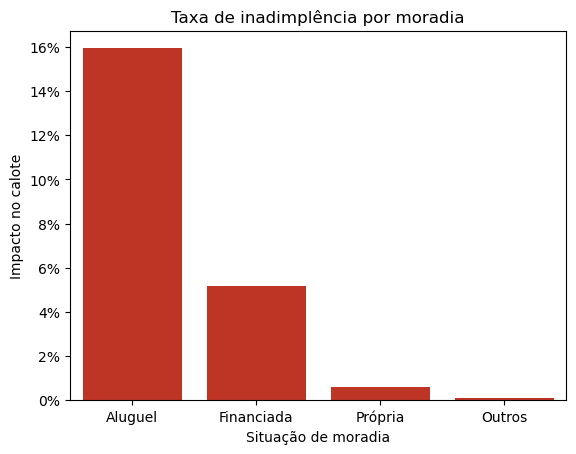

In [12]:

grafico1 = sns.barplot(data= proporçao_total, x="situacao_moradia" , y="impacto total", color= "#d8200c", errorbar=None)
plt.title("Taxa de inadimplência por moradia")
plt.xlabel("Situação de moradia")
plt.ylabel("Impacto no calote")
valores_y1 = grafico1.get_yticks()
grafico1.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y1])
plt.show()

## Qual perfil de moradia é o principal responsável pelos prejuízos totais da instituição?

Os clientes que moram de aluguel representam a maior parte de inadimplência do banco
15% em relação a todos os clientes do banco e mais de 30% em relação a todos os clientes que moram de aluguel

#Proporção de clientes inadimplentes em relação a categoria do mesmo 
Ex: inadimplentes com casa financiada  / pelo numero total de clientes com casa financida

C:\Users\Cauan\AppData\Local\Temp\ipykernel_22384\2967602995.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico1.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y1])


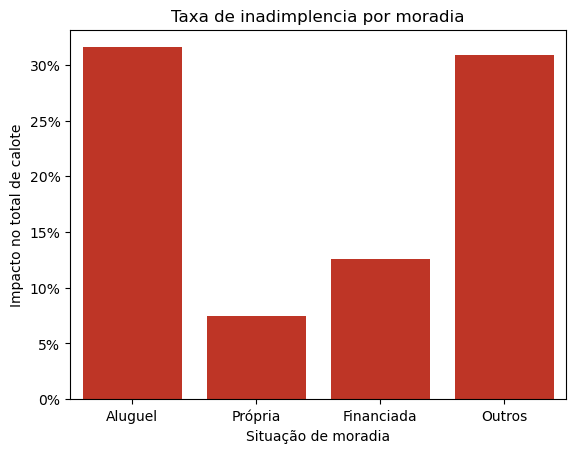

In [13]:

grafico1 = sns.barplot(data= df, x="situacao_moradia" , y="1_0_coluna", color= "#d8200c", errorbar=None)
plt.title("Taxa de inadimplencia por moradia")
plt.xlabel("Situação de moradia")
plt.ylabel("Impacto no total de calote")
valores_y1 = grafico1.get_yticks()
grafico1.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y1])
plt.show()

In [14]:
total_calote = df["1_0_coluna"].sum()
motivo_calote = (df.groupby("motivo_emprestimo")["1_0_coluna"].sum() / total_calote).sort_values(ascending=False).reset_index(name="taxa_calote")
motivo_calote


,motivo_emprestimo,taxa_calote
0,Saúde,0.228053
1,Consolidação de Dividas,0.209623
2,Educação,0.156303
3,Pessoal,0.154474
4,Reforma,0.132386
5,Empreendimento,0.119162


C:\Users\Cauan\AppData\Local\Temp\ipykernel_22384\3483643188.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico2.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y2])


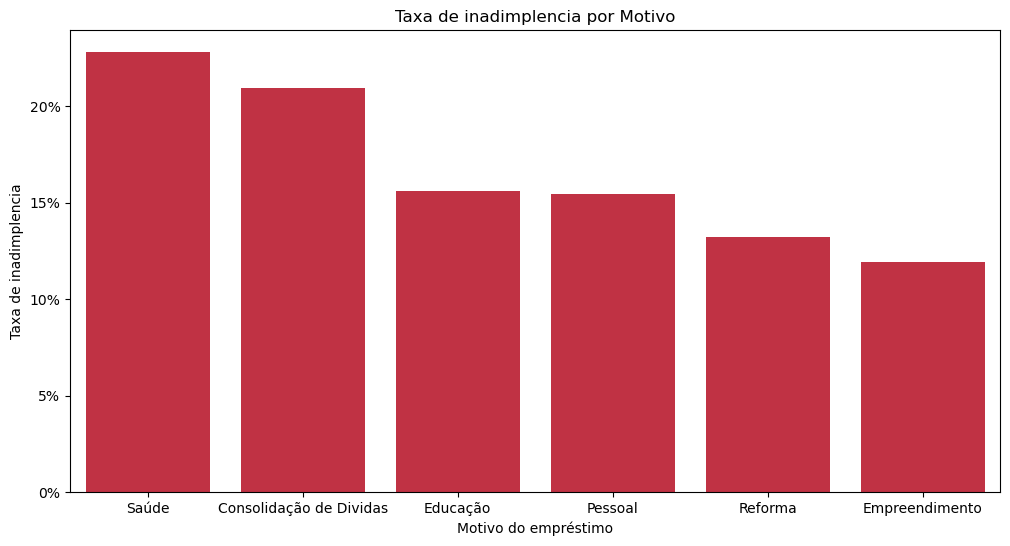

In [15]:
plt.figure(figsize=(12, 6))
grafico2 = sns.barplot(data= motivo_calote, x="motivo_emprestimo" , y="taxa_calote", color= "#d81a33", errorbar=None)
plt.title("Taxa de inadimplencia por Motivo")
plt.xlabel("Motivo do empréstimo")
plt.ylabel("Taxa de inadimplencia")
valores_y2 = grafico2.get_yticks()
grafico2.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y2])
plt.show()

## Se isolarmos apenas os maus pagadores, quais motivos os levaram a pedir dinheiro emprestado?

De todos os clientes que deram calote no banco, 22.8% deles usaram o motivo 'Saúde'
Com a Consolidação de dividas + Saúde descobrimos que quase 44% da base de calote é atrelado ao desespero e descontrole financeiro

In [16]:
#Definindo as faixa%
bins_renda = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 1.0]
labels_renda = ["Até 10%", "11-20%", "21-30%", "31-40%", "41-50%", "Mais de 50%"]
df["faixa_comprometimento"] = pd.cut(df["comprometimento_renda%"], bins=bins_renda, labels=labels_renda)


C:\Users\Cauan\AppData\Local\Temp\ipykernel_22384\211042366.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grafico3.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y3])


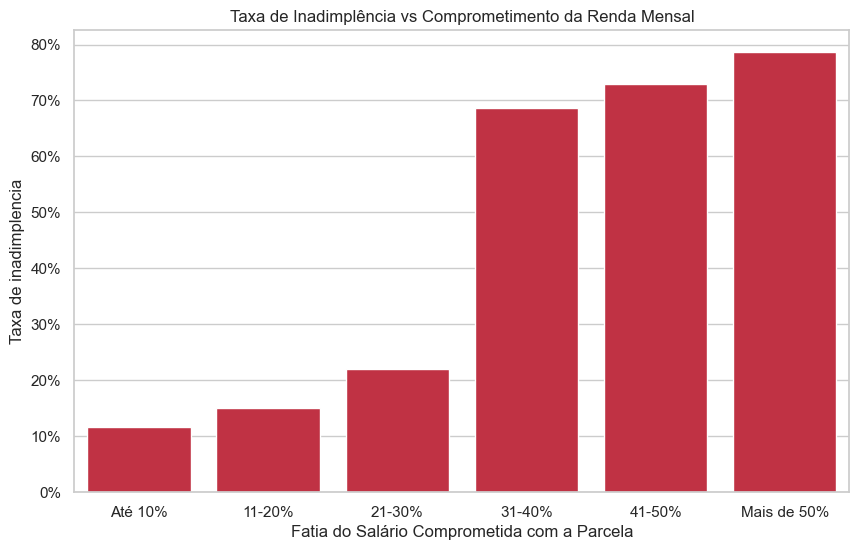

In [17]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
grafico3 = sns.barplot(data= df, x="faixa_comprometimento" , y="1_0_coluna", color= "#d81a33", errorbar=None)
plt.title("Taxa de Inadimplência vs Comprometimento da Renda Mensal")
plt.xlabel("Fatia do Salário Comprometida com a Parcela")
plt.ylabel("Taxa de inadimplencia")
valores_y3 = grafico3.get_yticks()
grafico3.set_yticklabels(['{:,.0f}%'.format(y * 100) for y in valores_y3])
plt.show()

## Qual é o limite do sufoco? A partir de qual porcentagem de comprometimento da renda o cliente para de pagar o banco?

A partir do momento em que a parcela do empréstimo ultrapassa 30% do salário, o gráfico explode! A taxa de calote salta de forma violenta de ~21% para absurdos 68% (na faixa dos 31-40%).
O banco deve criar uma trava sistêmica bloqueando a aprovação de qualquer empréstimo cuja parcela comprometa mais de 30% da renda anual do cliente, pois acima desse patamar a inadimplência dispara para quase 70%, tornando o risco financeiro insustentável.

Text(0.5, 1.0, 'Matriz de Correlação - Risco de Crédito')

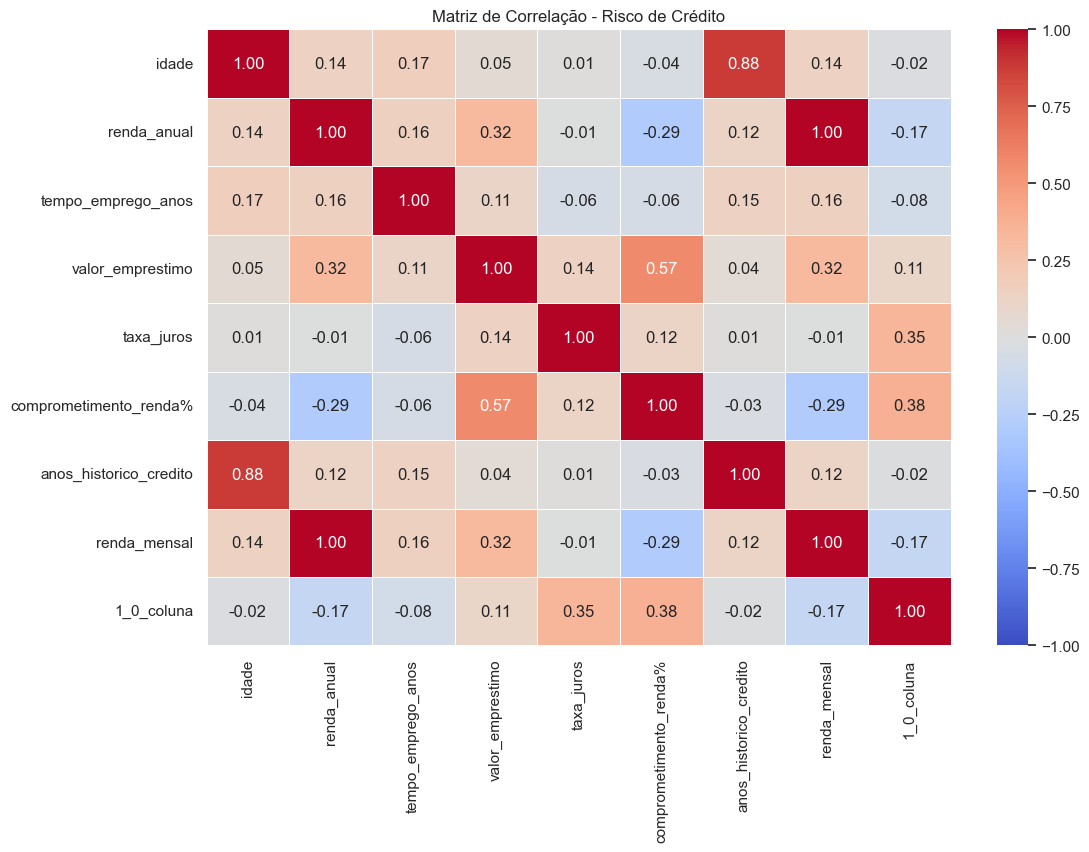

In [18]:
#  isolando as Colunas Numéricas

colunas_numericas = [
    'idade', 'renda_anual', 'tempo_emprego_anos', 'valor_emprestimo', 
    'taxa_juros', 'comprometimento_renda%', 'anos_historico_credito', 
    'renda_mensal', '1_0_coluna'
]

df_numerico = df[colunas_numericas]

matriz_corr = df_numerico.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Cores (Vermelho = Positivo, Azul = Negativo)
    fmt=".2f",           # Arredonda para 2 casas decimais
    linewidths=0.5,      # Cria linhas separando os quadrados para ficar limpo
    vmin=-1, vmax=1      # Fixa a escala visual de -1 a 1
)
plt.title('Matriz de Correlação - Risco de Crédito')

## Quais são os fatores ocultos que mais aceleram ou freiam a chance de um calote?

Comprometimento de renda, essa é a variável mais perigosa do banco. Quanto mais a parcela aperta o orçamento anual, maior a certeza do calote.

Renda anual, Ganhar bem reduz a chance de calote. É um sinal azul suave, não é uma regra perfeita (gente rica também dá calote), mas é um forte mitigador de risco.

In [19]:
print("\nTop Fatores que Aumentam ou Diminuem o Risco de Calote:")
print(matriz_corr['1_0_coluna'].sort_values(ascending=False))


Top Fatores que Aumentam ou Diminuem o Risco de Calote:
1_0_coluna                1.000000
comprometimento_renda%    0.379374
taxa_juros                0.345838
valor_emprestimo          0.105411
anos_historico_credito   -0.015504
idade                    -0.020721
tempo_emprego_anos       -0.084958
renda_mensal             -0.168506
renda_anual              -0.168507
Name: 1_0_coluna, dtype: float64
